Project Execution Framework (Analysis Summary)

Step 1: Data Collection

Dataset: 100,000 online food delivery orders

Real-world structured dataset

Likely contains both numerical + categorical features

Expect noisy, inconsistent, and missing values

Step 2: Data Understanding 

You have 25 features grouped into:

1. Customer Details
Age
Gender
Location
Customer ID
2. Order Information
Order ID
Order value
Order time
Order date
Payment method
Order status
3. Restaurant Attributes
Restaurant ID
Cuisine
Ratings
Preparation time
4. Delivery Performance
Delivery time
Distance
Delay
Delivery partner rating
5. Financial Metrics
Revenue
Discount
Delivery fee
Profit margin

This structure supports both operational and strategic analytics.

Step 3: Data Cleaning & Preprocessing

This is critical since we emphasized real-world noisy data.

Planned cleaning logic:

Issue Type	                            -    Strategy
Missing numeric values	                -    Mean / Median
Missing categorical values	            -    Mode
Outliers (delivery time, order value)	-    IQR capping or Z-score
Invalid ratings (>5)	                -    Clip to valid range
Negative profit margin	                -    Validate or recompute
Inconsistent categories	                -    Standardize (e.g., “Cash”, “cash”, “CASH”)
Logical issues	                        -    Cancelled orders should not have ratings

This step ensures model-ready, BI-ready data.

Step 4: Exploratory Data Analysis (EDA)

We are focusing on business insights, not just plots.

Key analysis directions:

1. Distribution Analysis
Order value
Delivery time
2. City & Cuisine Performance
Top cities by revenue
Top cuisines by demand
3. Demand Trends
Weekend vs Weekday
Hourly peak demand
4. Operational Analysis
Distance vs delay correlation
Delivery efficiency
5. Cancellation Analysis
Cancellation rate
Reasons
Financial impact
6. Correlation Matrix
Revenue vs Profit
Delivery time vs Rating
Distance vs Delay

This step uncovers hidden business patterns.

Step 5: Feature Engineering

Derived intelligent features:

Feature	                       -         Purpose
Order Day Type	               -         Demand behavior
Peak Hour Flag	               -         Operational planning
Profit Margin %	               -         Financial tracking
Delivery Performance Category  -    	 SLA monitoring
Age Groups	                   -         Customer segmentation

This step improves analytical depth.

Step 6: Data Storage (MySQL)

Final cleaned dataset:

Stored in MySQL
Proper data types
Indexed for faster queries
Inserted via SQLAlchemy

Enables:
Dashboard reporting
BI tools (e.g., Superset)
KPI monitoring

STEP 1: Data Collection

In [13]:
pip install pandas

897.72s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: /Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [12]:
import pandas as pd

# Load dataset
file_path = "ONINE_FOOD_DELIVERY_ANALYSIS.csv"
df = pd.read_csv(file_path)

# Quick preview
print(df.shape)
print(df.head())

(100000, 25)
    Order_ID Customer_ID  Customer_Age Customer_Gender     City     Area  \
0  ORD000001    CUST6948          19.0            Male      NaN  Central   
1  ORD000002    CUST6515           NaN          Female  Chennai    North   
2  ORD000003    CUST1765           NaN            Male    Delhi      NaN   
3  ORD000004    CUST2744           NaN            Male   Mumbai  Central   
4  ORD000005    CUST4389          57.0          Female  Chennai    South   

  Restaurant_ID Restaurant_Name Cuisine_Type  Order_Date  ... Final_Amount  \
0        RES936   Restaurant_29      Chinese  10/20/2024  ...          NaN   
1        RES689  Restaurant_419      Chinese   8/12/2024  ...       4849.0   
2        RES723  Restaurant_244      Arabian   12/8/2024  ...        737.0   
3        RES951  Restaurant_178      Chinese   10/8/2024  ...          NaN   
4        RES419  Restaurant_262      Chinese    2/4/2024  ...        352.0   

   Payment_Mode  Order_Status  Cancellation_Reason  Delivery_

STEP 2: Data Understanding

In [13]:
# Dataset overview
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 25 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   Order_ID             100000 non-null  object 
 1   Customer_ID          100000 non-null  object 
 2   Customer_Age         49907 non-null   float64
 3   Customer_Gender      75144 non-null   object 
 4   City                 83274 non-null   object 
 5   Area                 83315 non-null   object 
 6   Restaurant_ID        100000 non-null  object 
 7   Restaurant_Name      100000 non-null  object 
 8   Cuisine_Type         83115 non-null   object 
 9   Order_Date           98986 non-null   object 
 10  Order_Time           98002 non-null   object 
 11  Delivery_Time_Min    66641 non-null   float64
 12  Distance_km          66530 non-null   float64
 13  Order_Value          66673 non-null   float64
 14  Discount_Applied     83285 non-null   float64
 15  Final_Amount      

In [14]:
# Summary statistics
print(df.describe())

       Customer_Age  Delivery_Time_Min   Distance_km   Order_Value  \
count  49907.000000       66641.000000  66530.000000  66673.000000   
mean      38.976516         127.475923     16.449242   2081.830126   
std       12.372157          90.805839     12.256742   1553.628891   
min       18.000000          20.000000      1.000000    150.000000   
25%       28.000000          45.000000      5.470000    673.000000   
50%       39.000000         120.000000      9.970000   1197.000000   
75%       50.000000         210.000000     27.430000   3494.000000   
max       60.000000         300.000000     40.000000   5000.000000   

       Discount_Applied  Final_Amount  Delivery_Rating  Restaurant_Rating  \
count      83285.000000  44303.000000     83477.000000      100000.000000   
mean          93.936243   1961.101190         2.991531           4.249680   
std          108.209904   1557.354417         1.414108           0.722554   
min            0.000000   -150.000000         1.000000       

In [15]:
# Check missing values
print(df.isnull().sum())

Order_ID                   0
Customer_ID                0
Customer_Age           50093
Customer_Gender        24856
City                   16726
Area                   16685
Restaurant_ID              0
Restaurant_Name            0
Cuisine_Type           16885
Order_Date              1014
Order_Time              1998
Delivery_Time_Min      33359
Distance_km            33470
Order_Value            33327
Discount_Applied       16715
Final_Amount           55697
Payment_Mode           19911
Order_Status               0
Cancellation_Reason    90969
Delivery_Partner_ID        0
Delivery_Rating        16523
Restaurant_Rating          0
Order_Day                  0
Peak_Hour              32962
Profit_Margin              0
dtype: int64


In [16]:
# Check unique values in categorical columns
categorical_cols = df.select_dtypes(include='object').columns
for col in categorical_cols:
    print(f"{col}:", df[col].nunique())

Order_ID: 100000
Customer_ID: 8999
Customer_Gender: 3
City: 5
Area: 5
Restaurant_ID: 900
Restaurant_Name: 500
Cuisine_Type: 5
Order_Date: 365
Order_Time: 1
Payment_Mode: 4
Order_Status: 2
Cancellation_Reason: 3
Delivery_Partner_ID: 900
Order_Day: 2
Peak_Hour: 2


STEP 3: Data Cleaning & Preprocessing

3.1 Handling Missing Values

In [17]:
# Numeric columns fill with median
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

# Categorical columns fill with mode
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])    

/var/folders/jt/k_07mc7973q8qdd8r2gf58xr0000gn/T/ipykernel_1174/4111891856.py:9: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].fillna(df[col].mode()[0])


3.2 Removing / Capping Outliers (IQR Method)

In [18]:
print(df.columns)

Index(['Order_ID', 'Customer_ID', 'Customer_Age', 'Customer_Gender', 'City',
       'Area', 'Restaurant_ID', 'Restaurant_Name', 'Cuisine_Type',
       'Order_Date', 'Order_Time', 'Delivery_Time_Min', 'Distance_km',
       'Order_Value', 'Discount_Applied', 'Final_Amount', 'Payment_Mode',
       'Order_Status', 'Cancellation_Reason', 'Delivery_Partner_ID',
       'Delivery_Rating', 'Restaurant_Rating', 'Order_Day', 'Peak_Hour',
       'Profit_Margin'],
      dtype='object')


In [19]:
def cap_outliers(column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    df[column] = df[column].clip(lower, upper)

# Apply to key columns
cap_outliers('Delivery_Time_Min')
cap_outliers('Order_Value')

3.3 Correct Invalid Values

In [20]:
# Ratings greater than 5
df['Restaurant_Rating'] = df['Restaurant_Rating'].clip(0, 5)

# Negative profit margin correction
df.loc[df['Profit_Margin'] < 0, 'Profit_Margin'] = 0

3.4 Standardizing Categorical Values

In [21]:
df['Payment_Mode'] = df['Payment_Mode'].str.lower().str.strip()
df['City'] = df['City'].str.title()
df['Cuisine_Type'] = df['Cuisine_Type'].str.title()

3.5 Logical Consistency

In [22]:
# Cancelled orders should not have rating
df.loc[df['Order_Status'] == 'Cancelled', 'Restaurant_Rating'] = None

STEP 4: Exploratory Data Analysis (EDA)

In [23]:
pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: /Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [24]:
pip install seaborn

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: /Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

4.1 Distribution of Order Value

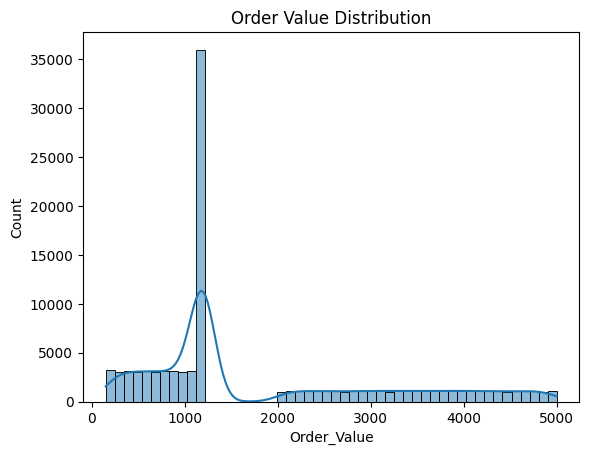

In [26]:
sns.histplot(df['Order_Value'], bins=50, kde=True)
plt.title("Order Value Distribution")
plt.show()

4.2 Delivery Time Distribution

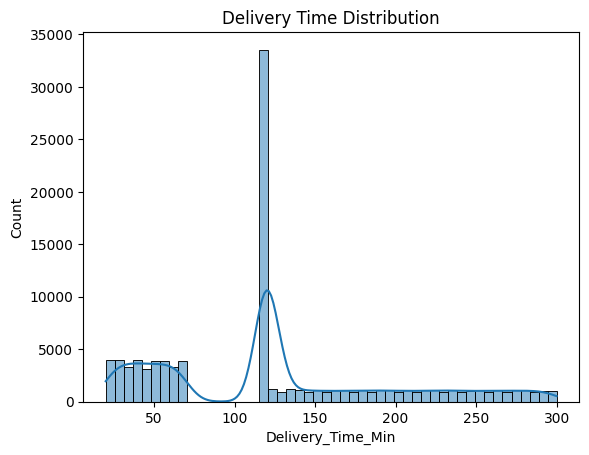

In [27]:
sns.histplot(df['Delivery_Time_Min'], bins=50, kde=True)
plt.title("Delivery Time Distribution")
plt.show()

4.3 City-wise Orders

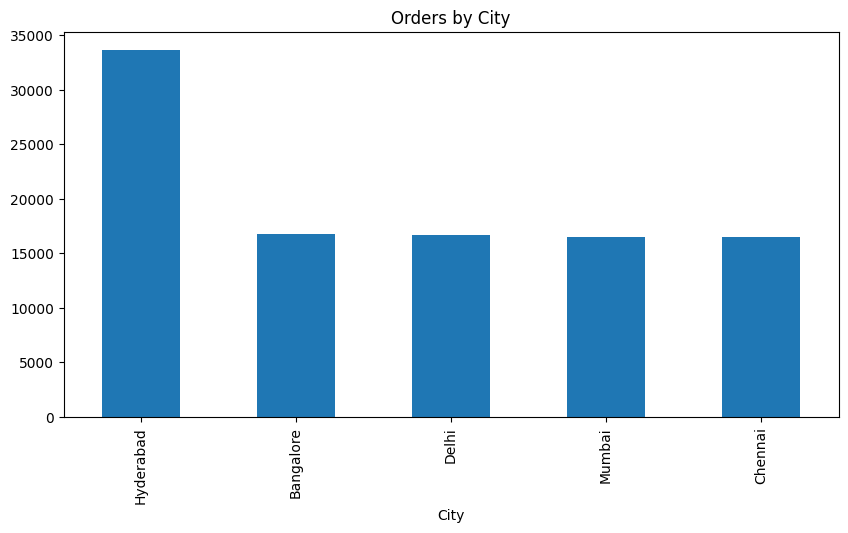

In [28]:
city_orders = df['City'].value_counts()
city_orders.plot(kind='bar', figsize=(10,5))
plt.title("Orders by City")
plt.show()

4.4 Weekend vs Weekday

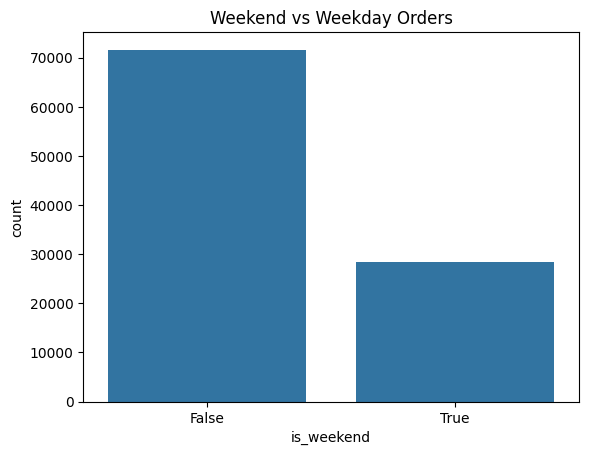

In [30]:
df['order_date'] = pd.to_datetime(df['Order_Date'])
df['day_of_week'] = df['order_date'].dt.day_name()

df['is_weekend'] = df['day_of_week'].isin(['Saturday', 'Sunday'])

sns.countplot(x='is_weekend', data=df)
plt.title("Weekend vs Weekday Orders")
plt.show()

4.5 Distance vs Delivery Delay

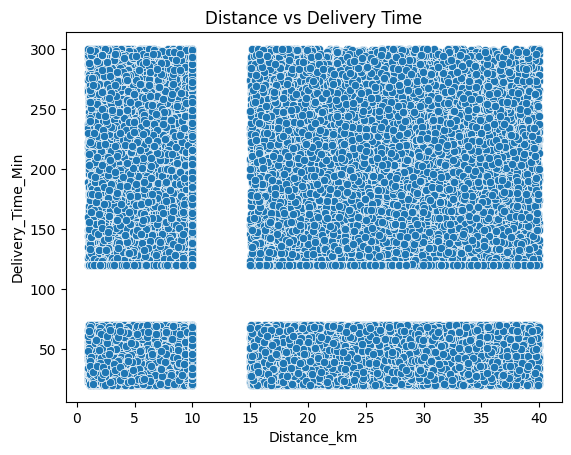

In [31]:
sns.scatterplot(x='Distance_km', y='Delivery_Time_Min', data=df)
plt.title("Distance vs Delivery Time")
plt.show()

4.6 Correlation Matrix

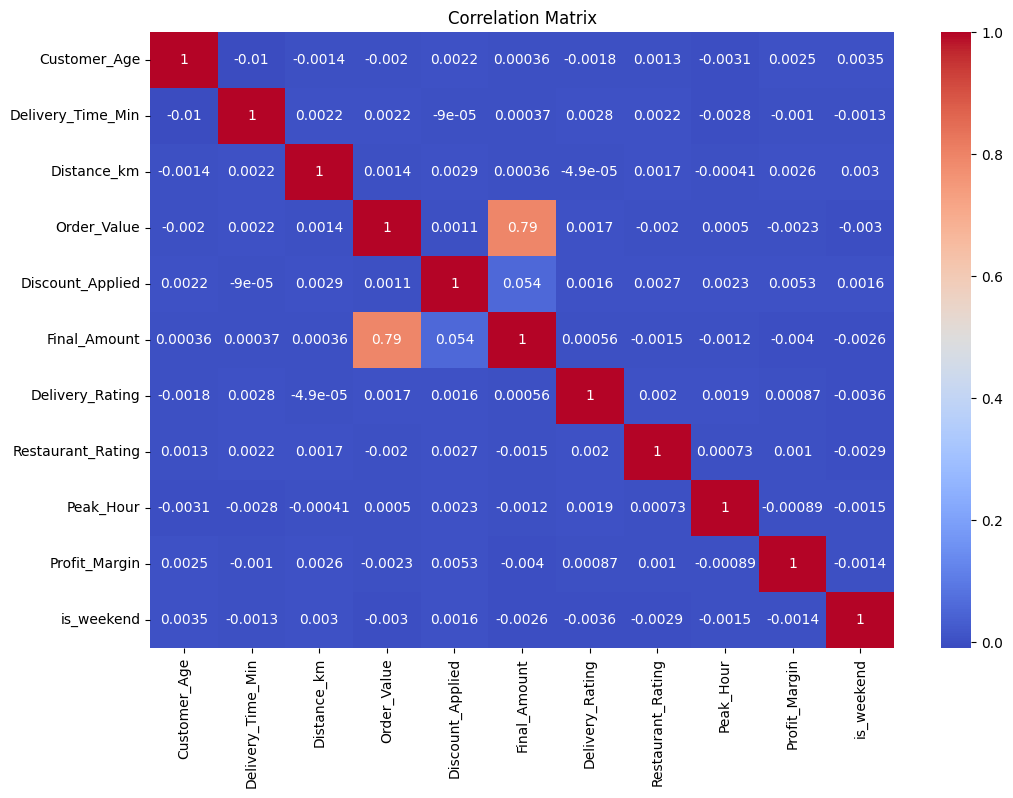

In [32]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

STEP 5: Feature Engineering
5.1 Order Day Type

In [33]:
df['order_day_type'] = df['day_of_week'].apply(
    lambda x: 'Weekend' if x in ['Saturday', 'Sunday'] else 'Weekday'
)
df['order_day_type']

0        Weekend
1        Weekday
2        Weekend
3        Weekday
4        Weekend
          ...   
99995    Weekday
99996    Weekday
99997    Weekday
99998    Weekday
99999    Weekday
Name: order_day_type, Length: 100000, dtype: object

5.2 Peak Hour Indicator

In [34]:
df['order_time'] = pd.to_datetime(df['Order_Time'])
df['hour'] = df['order_time'].dt.hour

df['is_peak_hour'] = df['hour'].apply(
    lambda x: 1 if (12 <= x <= 14) or (18 <= x <= 22) else 0
)

5.3 Profit Margin Percentage

In [35]:
df['profit_margin_pct'] = (df['Profit_Margin'] / df['Order_Value']) * 100

5.4 Delivery Performance Category

In [36]:
def delivery_category(x):
    if x <= 30:
        return 'Fast'
    elif x <= 45:
        return 'On-Time'
    else:
        return 'Delayed'

df['delivery_performance'] = df['Delivery_Time_Min'].apply(delivery_category)

5.5 Customer Age Groups

In [37]:
def age_group(age):
    if age < 18:
        return 'Teen'
    elif age < 30:
        return 'Young Adult'
    elif age < 45:
        return 'Adult'
    else:
        return 'Senior'

df['age_group'] = df['Customer_Age'].apply(age_group)

STEP 6: Data Storage in MySQL
6.1 Install Required Libraries

In [38]:
pip install sqlalchemy mysql-connector-python

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: /Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


6.2 Create MySQL Connection

In [39]:
from sqlalchemy import create_engine

username = "root"
password = "12345678"
host = "127.0.0.1"
database = "FoodDelivery"

engine = create_engine(f"mysql+mysqlconnector://{username}:{password}@{host}/{database}")

6.3 Store Cleaned Data

In [40]:
print(df.columns)

Index(['Order_ID', 'Customer_ID', 'Customer_Age', 'Customer_Gender', 'City',
       'Area', 'Restaurant_ID', 'Restaurant_Name', 'Cuisine_Type',
       'Order_Date', 'Order_Time', 'Delivery_Time_Min', 'Distance_km',
       'Order_Value', 'Discount_Applied', 'Final_Amount', 'Payment_Mode',
       'Order_Status', 'Cancellation_Reason', 'Delivery_Partner_ID',
       'Delivery_Rating', 'Restaurant_Rating', 'Order_Day', 'Peak_Hour',
       'Profit_Margin', 'order_date', 'day_of_week', 'is_weekend',
       'order_day_type', 'order_time', 'hour', 'is_peak_hour',
       'profit_margin_pct', 'delivery_performance', 'age_group'],
      dtype='object')


In [41]:
df = df.drop('Order_Date', axis=1)
df = df.drop('Order_Time', axis=1)

In [43]:
df.to_sql(
    name="onlinefoods",
    con=engine,
    if_exists="replace",  # use 'append' in production
    index=False
)

print("Data successfully stored in MySQL!")

Data successfully stored in MySQL!


Final Pipeline Flow

Load Data
   ↓
Understand Structure
   ↓
Clean & Preprocess
   ↓
Perform EDA
   ↓
Feature Engineering
   ↓
Store in MySQL

Below is a complete Analyst-Level EDA & Analytics Code Implementation based on your task list.

This assumes:

Data already cleaned

Feature engineering completed

order_date converted to datetime

MySQL storage already optional

Columns like:

customer_id
customer_age
order_value
profit_margin
discount
city
cuisine
delivery_time
distance_km
delivery_rating
restaurant_id
restaurant_rating
order_status
payment_method
cancellation_reason

1. CUSTOMER & ORDER ANALYSIS
1.1 Top-Spending Customers

In [44]:
print(df.columns)

Index(['Order_ID', 'Customer_ID', 'Customer_Age', 'Customer_Gender', 'City',
       'Area', 'Restaurant_ID', 'Restaurant_Name', 'Cuisine_Type',
       'Delivery_Time_Min', 'Distance_km', 'Order_Value', 'Discount_Applied',
       'Final_Amount', 'Payment_Mode', 'Order_Status', 'Cancellation_Reason',
       'Delivery_Partner_ID', 'Delivery_Rating', 'Restaurant_Rating',
       'Order_Day', 'Peak_Hour', 'Profit_Margin', 'order_date', 'day_of_week',
       'is_weekend', 'order_day_type', 'order_time', 'hour', 'is_peak_hour',
       'profit_margin_pct', 'delivery_performance', 'age_group'],
      dtype='object')


Customer_ID
CUST5267    53017.0
CUST1606    52411.0
CUST6706    49269.0
CUST6252    48085.0
CUST1239    47793.0
CUST4431    46765.0
CUST5534    46538.0
CUST1968    46381.0
CUST6457    46241.0
CUST6293    46031.0
Name: Order_Value, dtype: float64


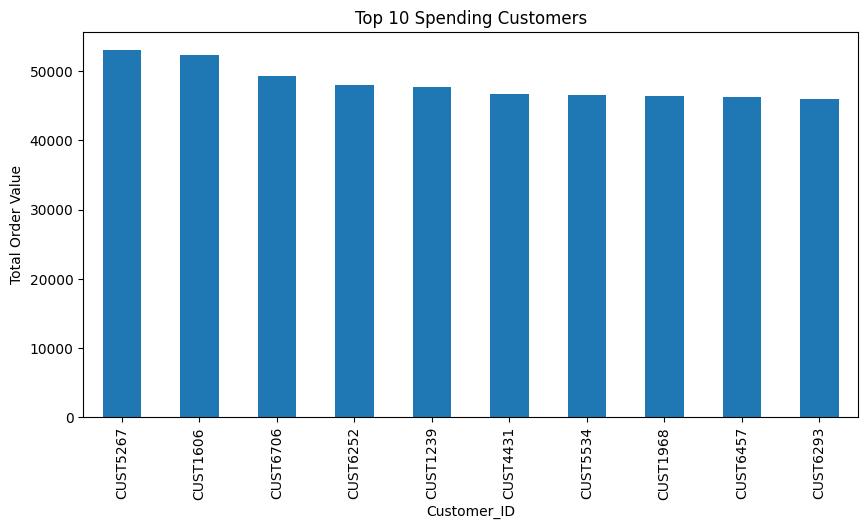

In [45]:
top_customers = (
    df.groupby('Customer_ID')['Order_Value']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(top_customers)

top_customers.plot(kind='bar', figsize=(10,5))
plt.title("Top 10 Spending Customers")
plt.ylabel("Total Order Value")
plt.show()

1.2 Age Group vs Order Value

age_group
Young Adult    1791.200288
Senior         1786.386532
Adult          1786.218735
Name: Order_Value, dtype: float64


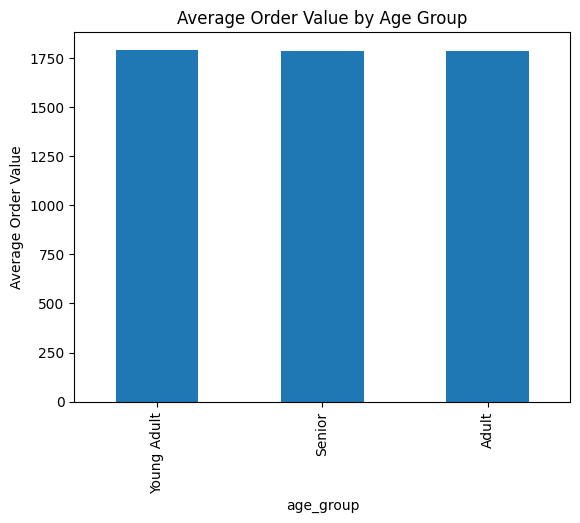

In [46]:
age_group_analysis = (
    df.groupby('age_group')['Order_Value']
    .mean()
    .sort_values(ascending=False)
)

print(age_group_analysis)

age_group_analysis.plot(kind='bar')
plt.title("Average Order Value by Age Group")
plt.ylabel("Average Order Value")
plt.show()

1.3 Weekend vs Weekday Patterns

                count         mean          sum
order_day_type                                 
Weekday         71632  1789.488971  128184674.0
Weekend         28368  1780.513431   50509605.0


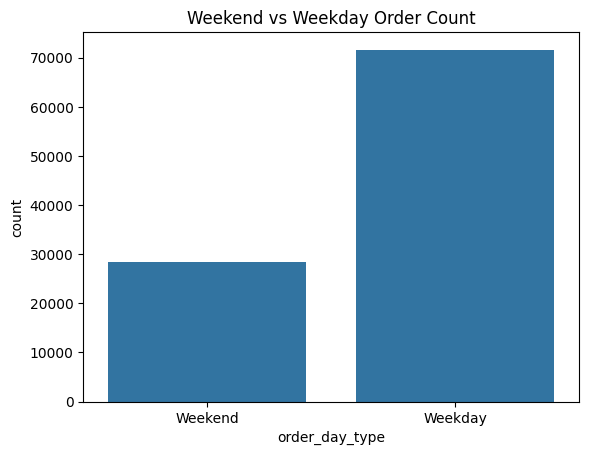

In [47]:
weekend_analysis = (
    df.groupby('order_day_type')['Order_Value']
    .agg(['count', 'mean', 'sum'])
)

print(weekend_analysis)

sns.countplot(x='order_day_type', data=df)
plt.title("Weekend vs Weekday Order Count")
plt.show()

2. REVENUE & PROFIT ANALYSIS
2.1 Monthly Revenue Trends

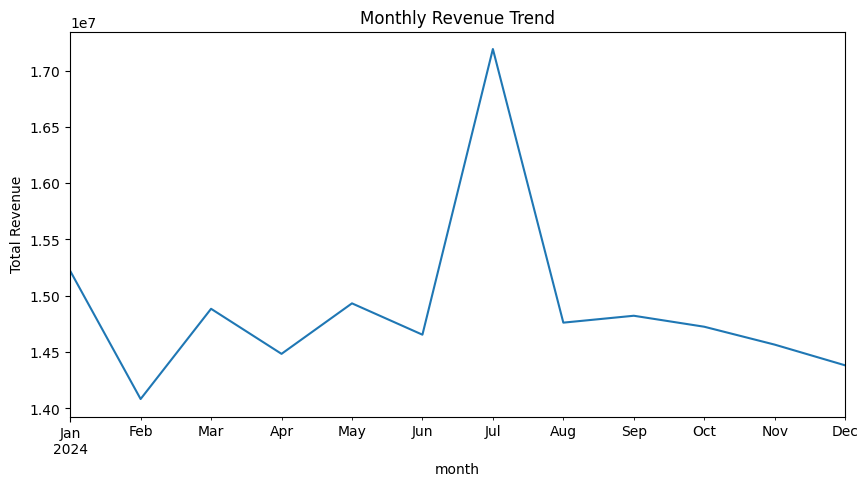

In [48]:
df['month'] = df['order_date'].dt.to_period('M')

monthly_revenue = (
    df.groupby('month')['Order_Value']
    .sum()
)

monthly_revenue.plot(figsize=(10,5))
plt.title("Monthly Revenue Trend")
plt.ylabel("Total Revenue")
plt.show()

2.2 Impact of Discounts on Profit

                   Discount_Applied  profit_margin_pct
Discount_Applied           1.000000           0.000583
profit_margin_pct          0.000583           1.000000


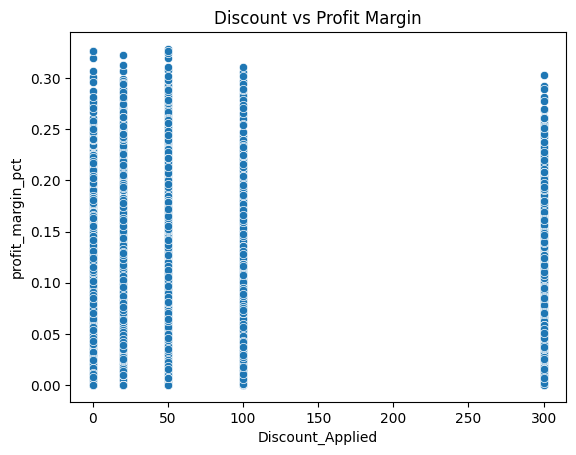

In [49]:
discount_profit = df[['Discount_Applied', 'profit_margin_pct']].corr()
print(discount_profit)

sns.scatterplot(x='Discount_Applied', y='profit_margin_pct', data=df)
plt.title("Discount vs Profit Margin")
plt.show()

Interpretation:
Negative correlation → High discounts reduce profit.

2.3 High-Revenue Cities

City
Hyderabad    59943369.0
Bangalore    30081629.0
Delhi        29686686.0
Chennai      29560961.0
Mumbai       29421634.0
Name: Order_Value, dtype: float64


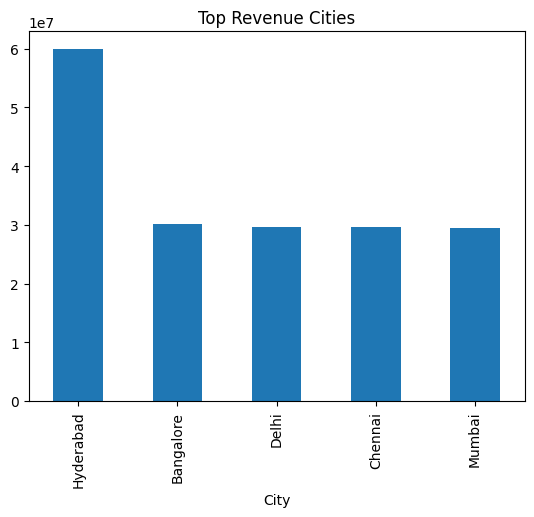

In [50]:
city_revenue = (
    df.groupby('City')['Order_Value']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(city_revenue)

city_revenue.plot(kind='bar')
plt.title("Top Revenue Cities")
plt.show()

2.4 High-Revenue Cuisines

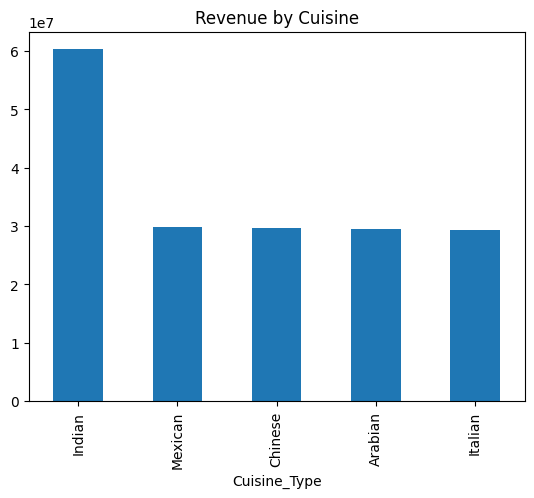

In [51]:
cuisine_revenue = (
    df.groupby('Cuisine_Type')['Order_Value']
    .sum()
    .sort_values(ascending=False)
)

cuisine_revenue.plot(kind='bar')
plt.title("Revenue by Cuisine")
plt.show()

3. DELIVERY PERFORMANCE
3.1 Average Delivery Time by City

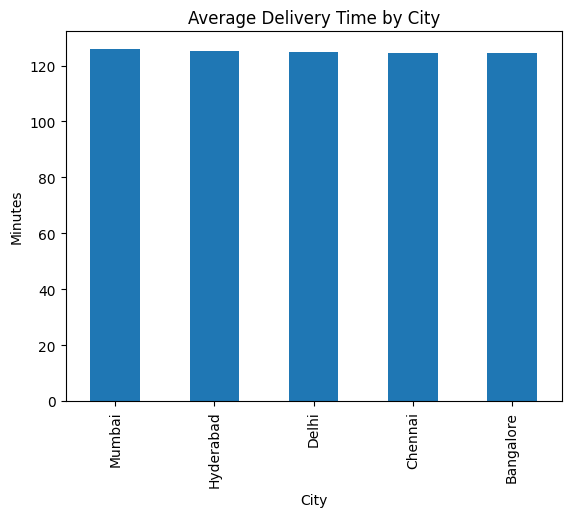

In [52]:
delivery_city = (
    df.groupby('City')['Delivery_Time_Min']
    .mean()
    .sort_values(ascending=False)
)

delivery_city.plot(kind='bar')
plt.title("Average Delivery Time by City")
plt.ylabel("Minutes")
plt.show()

3.2 Distance vs Delivery Delay

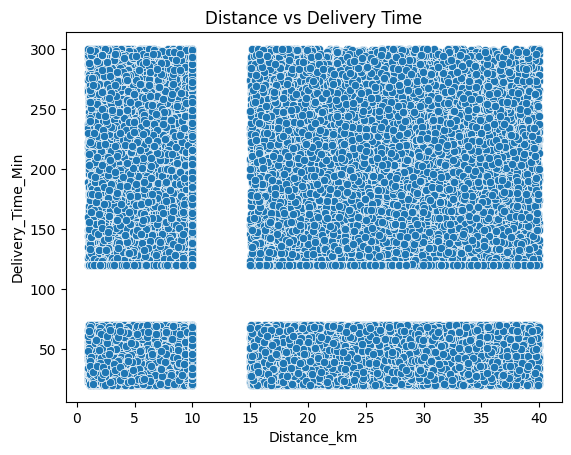

                   Distance_km  Delivery_Time_Min
Distance_km           1.000000           0.002227
Delivery_Time_Min     0.002227           1.000000


In [53]:
sns.scatterplot(x='Distance_km', y='Delivery_Time_Min', data=df)
plt.title("Distance vs Delivery Time")
plt.show()

print(df[['Distance_km', 'Delivery_Time_Min']].corr())

3.3 Delivery Rating vs Delivery Time

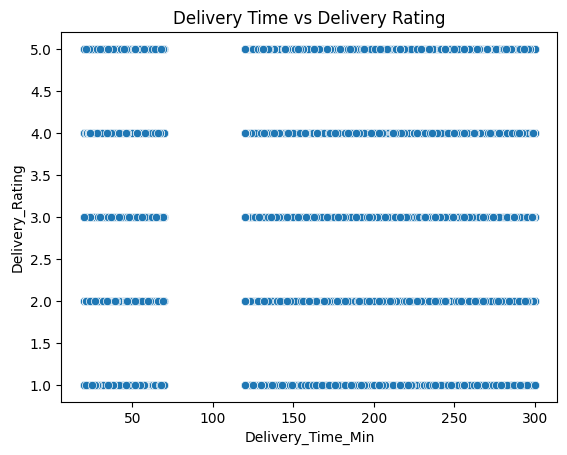

                   Delivery_Time_Min  Delivery_Rating
Delivery_Time_Min           1.000000         0.002845
Delivery_Rating             0.002845         1.000000


In [54]:
sns.scatterplot(x='Delivery_Time_Min', y='Delivery_Rating', data=df)
plt.title("Delivery Time vs Delivery Rating")
plt.show()

print(df[['Delivery_Time_Min', 'Delivery_Rating']].corr())

Typically negative correlation expected.

4. RESTAURANT PERFORMANCE
4.1 Top-Rated Restaurants

In [55]:
top_restaurants = (
    df.groupby('Restaurant_ID')['Restaurant_Rating']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

print(top_restaurants)

Restaurant_ID
RES862    4.404211
RES605    4.396512
RES395    4.392523
RES344    4.391954
RES206    4.391429
RES869    4.381579
RES371    4.379808
RES984    4.375258
RES810    4.366279
RES920    4.363964
Name: Restaurant_Rating, dtype: float64


4.2 Cancellation Rate by Restaurant

In [56]:
cancel_rate = (
    df.groupby('Restaurant_ID')['Order_Status']
    .apply(lambda x: (x == 'Cancelled').mean())
    .sort_values(ascending=False)
    .head(10)
)

print(cancel_rate)

Restaurant_ID
RES871    0.254902
RES481    0.245098
RES497    0.239130
RES344    0.236842
RES874    0.235849
RES921    0.234234
RES117    0.232558
RES455    0.232143
RES607    0.230000
RES384    0.229508
Name: Order_Status, dtype: float64


4.3 Cuisine-wise Performance

In [57]:
cuisine_perf = (
    df.groupby('Cuisine_Type')
    .agg({
        'Order_Value': 'sum',
        'Restaurant_Rating': 'mean',
        'Order_ID': 'count'
    })
    .sort_values(by='Order_Value', ascending=False)
)

print(cuisine_perf)

              Order_Value  Restaurant_Rating  Order_ID
Cuisine_Type                                          
Indian         60314705.0           4.200875     33570
Mexican        29765117.0           4.195174     16602
Chinese        29757833.0           4.189586     16651
Arabian        29481102.0           4.206261     16658
Italian        29375522.0           4.206893     16519


5. OPERATIONAL INSIGHTS
5.1 Peak Hour Demand Analysis

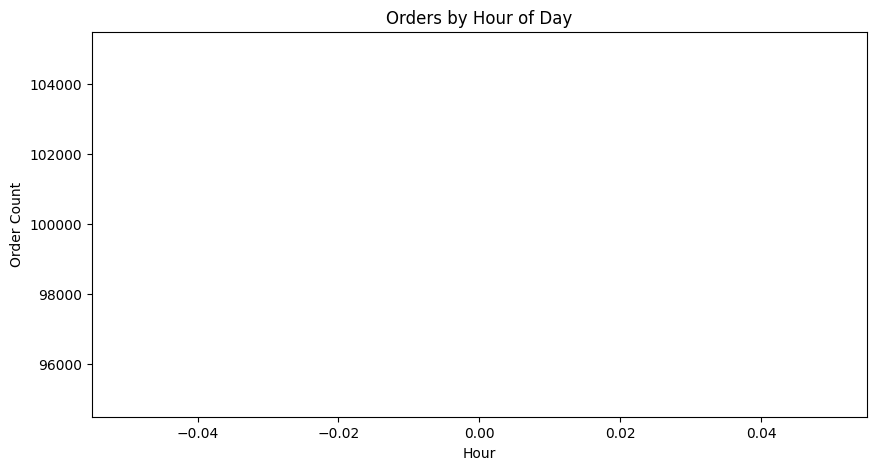

In [ ]:
df['order_time'] = pd.to_datetime(df['order_time'], format='%H:%M')

df['hour'] = df['order_time'].dt.hour

peak_hour_orders = df.groupby('hour')['Order_ID'].count()

peak_hour_orders.plot(figsize=(10,5))

plt.title("Orders by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Order Count")

plt.show()

Helps optimize delivery staff scheduling.

5.2 Payment Mode Preferences

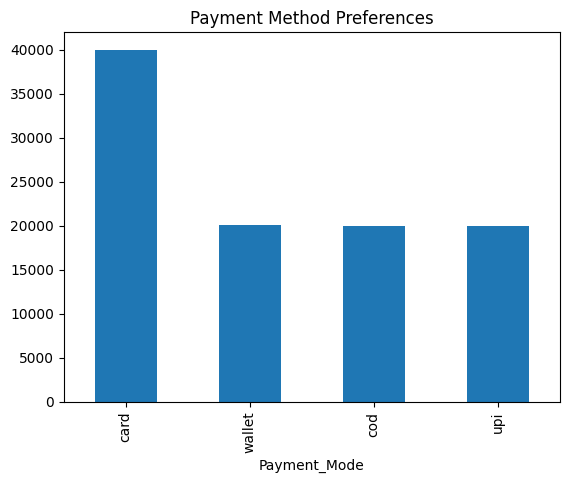

In [104]:
payment_mode = df['Payment_Mode'].value_counts()

payment_mode.plot(kind='bar')
plt.title("Payment Method Preferences")
plt.show()

5.3 Cancellation Reason Analysis

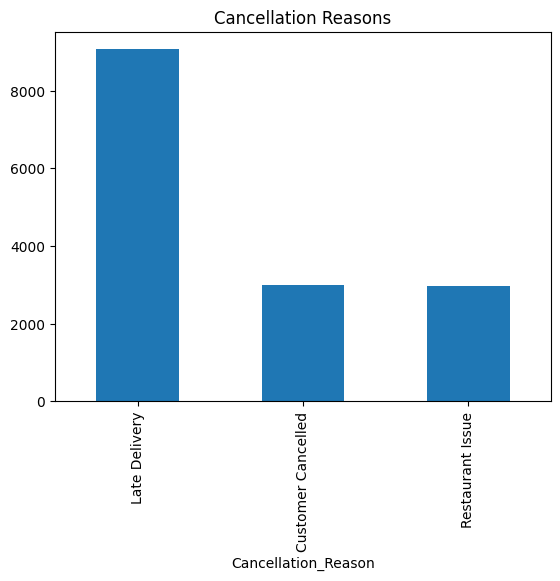

In [106]:
cancel_reason = (
    df[df['Order_Status'] == 'Cancelled']
    ['Cancellation_Reason']
    .value_counts()
)

cancel_reason.plot(kind='bar')
plt.title("Cancellation Reasons")
plt.show()

BONUS: KPI Summary Table

In [111]:
kpi_summary = {
    "Total Orders": len(df),
    "Total Revenue": df['Order_Value'].sum(),
    "Total Profit": df['profit_margin_pct'].sum(),
    "Average Delivery Time": df['Delivery_Time_Min'].mean(),
    "Cancellation Rate (%)": (df['Order_Status'] == 'Cancelled').mean() * 100
}

# print(kpi_summary)
for key, value in kpi_summary.items():
    print(f"{key}: {value}")

Total Orders: 100000
Total Revenue: 178694279.0
Total Profit: 1870.5214474482414
Average Delivery Time: 124.98203
Cancellation Rate (%): 15.036
